# Neural Networks Approach

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
import matplotlib.pyplot as plt

# Covid

In [2]:
df_covid = pd.read_csv('https://raw.githubusercontent.com/danielgvb/thesis/refs/heads/main/Data/silver/covid_data_weekly.csv')
df_covid.head()

,country,date,new_cases,cases
0,Brazil,2020-01-20,0,0
1,Brazil,2020-01-27,0,0
2,Brazil,2020-02-03,0,0
3,Brazil,2020-02-10,0,0
4,Brazil,2020-02-17,0,0


# Understanding the GRU Model for COVID-19 Forecasting

## 1. What is the Input to the GRU Network?
The input to the GRU model is a **sequence of past COVID-19 cases**. Given a time series:

$$ y_1, y_2, y_3, \dots, y_T $$

We create **overlapping sequences** of length \( seq\_length = 5 \) to predict the next value.

For example, if the time series looks like:
\[
\{100, 150, 180, 220, 250, ?\}
\]

Then the **GRU input** is:

$$ X = [100, 150, 180, 220, 250] $$

And the target (to predict) is:

$$ y = \text{Next value in series} $$

Thus, each training sample consists of:

$$ X = [y_t, y_{t-1}, y_{t-2}, y_{t-3}, y_{t-4}] $$
$$ y = y_{t+1} $$

## 2. What is the GRU Forecasting?
The GRU model predicts **the next time step** given the past 5 values.

- Given **5 past cases**, it predicts the **6th case**.
- Given **6 past cases**, it predicts the **7th case**.
- This process continues until the end of the dataset.

## 3. Train-Test Split Strategy
We split the dataset **before creating sequences**:

- **Train data:** First 80% of cases
- **Test data:** Last 20% of cases

## 4. Model Training Process
1. **Normalization:** Cases are scaled between 0 and 1.
2. **Train-Test Split:** Data is divided into 80% training and 20% testing.
3. **Sequence Generation:** Each sample consists of **5 previous timesteps**.
4. **GRU Training:** The model learns patterns in training data.
5. **Prediction:** The trained model forecasts the entire dataset.
6. **Evaluation:** RMSE & R² are computed only on the test set.

## 5. Summary Table
| Step | Action |
|------|--------|
| 1. Data Processing | Normalize cases, create sequences |
| 2. Input to GRU | Past 5 values (e.g., Days 1-5) |
| 3. Target (y) | Next value (e.g., Day 6) |
| 4. Training | GRU learns patterns on train data (80%) |
| 5. Forecasting | Predicts entire series (Train + Test) |
| 6. Evaluation | Computes RMSE & R² only on test set |

## 6. Key Takeaways
- The GRU network sees **5 past cases** as input to predict the **next case**.
- It is a **one-step-ahead forecasting model**.
- The model is trained **only on training data but predicts for the entire dataset**.
- **Test set evaluation is separate** to prevent overfitting.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━

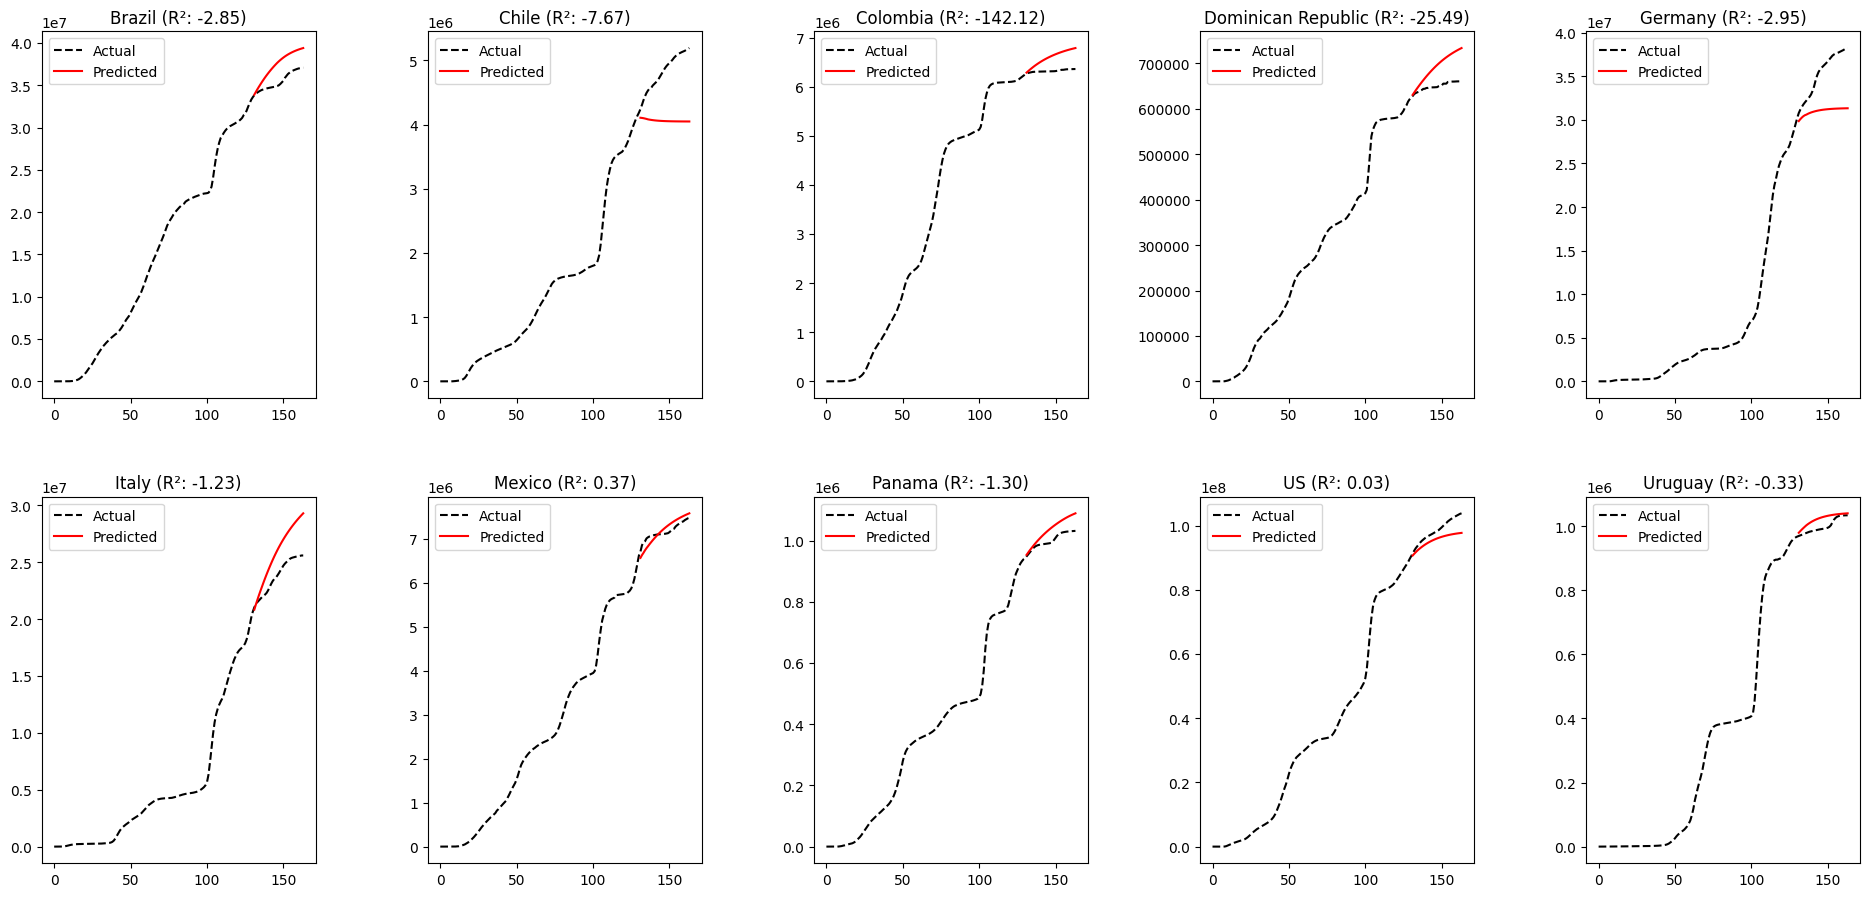

In [5]:
from tensorflow.keras import backend as K          # to clear memory
# Function to create sequences for GRU
def create_sequences(data, seq_length=5):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

# Get unique countries
countries = df_covid['country'].unique()

# initiate a metrics dict
metrics = {}

# Create subplots
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
fig.tight_layout(pad=5.0)

seq_length = 5

# Loop through each country
for i, country in enumerate(countries):
    df_country = df_covid[df_covid['country'] == country].copy()

    y = df_country['cases'].values.reshape(-1, 1)
    scaler = MinMaxScaler()
    y_scaled = scaler.fit_transform(y)

    # Train-test split (80% train, 20% test)
    train_size = int(len(y_scaled) * 0.8)
    train, test = y_scaled[:train_size], y_scaled[train_size:]

    # Create sequences for train set
    X_train_val, y_train_val = create_sequences(train, seq_length)
    X_train_val = X_train_val.reshape((X_train_val.shape[0], seq_length, 1))
    X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42, shuffle = True)

    # Build GRU model
    model = Sequential()
    model.add(GRU(50, activation='relu', input_shape=(seq_length, 1)))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer='adam')

    # Train model
    model.fit(X_train, y_train, epochs=50, batch_size=72, verbose=0, shuffle=False, validation_data=(X_val, y_val))

    # Iterative predictions on test data
    predictions = []
    current_batch = train[-seq_length:].reshape((1, seq_length, 1))

    for j in range(len(test)):
        pred = model.predict(current_batch)[0]
        predictions.append(pred)
        current_batch = np.append(current_batch[:, 1:, :], [[pred]], axis=1)


    # Inverse transform predictions
    predictions = scaler.inverse_transform(np.array(predictions).reshape(-1, 1))
    actual = scaler.inverse_transform(test)
    # clear memory
    K.clear_session()   # free GPU/CPU graph memory

    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(actual, predictions))
    r2 = r2_score(actual, predictions)
    metrics[country] = {'RMSE': rmse, 'R2': r2}

    # Print metrics
    print(f"Country: {country}, RMSE: {rmse:.2f}, R2: {r2:.2f}")

    # Plot actual vs predicted
    row = i // 5
    col = i % 5
    axes[row, col].plot(range(len(y_scaled)), scaler.inverse_transform(y_scaled), label='Actual', color='black', linestyle='dashed')
    axes[row, col].plot(range(train_size, train_size + len(predictions)), predictions, label='Predicted', color='red')
    axes[row, col].set_title(f"{country} (R²: {r2:.2f})")
    axes[row, col].legend()



plt.show()

In [6]:
# create a metrics dataframe based on the dict metrics
metrics_df = pd.DataFrame.from_dict(metrics, orient='index')
metrics_df.reset_index(inplace=True)
metrics_df.rename(columns={'index': 'country'}, inplace=True)
metrics_df

,country,RMSE,R2
0,Brazil,2.086700e+06,-2.854221
1,Chile,8.176642e+05,-7.672296
2,Colombia,2.967024e+05,-142.117734
3,Dominican Republic,4.720123e+04,-25.492951
4,Germany,4.845702e+06,-2.947492
5,Italy,2.282098e+06,-1.230301
6,Mexico,1.432925e+05,0.365507
7,Panama,3.769578e+04,-1.295429
8,US,3.482629e+06,0.025182
9,Uruguay,2.535176e+04,-0.331144


## Non-Cheating RNN

In [9]:
from functools import reduce

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Brazil       | RMSE: 1488749.21 | R2:  -0.96


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Chile        | RMSE: 968228.82 | R2: -11.16


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

Panama       | RMSE: 59124.54 | R2:  -4.65


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


US           | RMSE: 13373617.27 | R2: -13.37


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Uruguay      | RMSE: 176237.09 | R2: -63.33


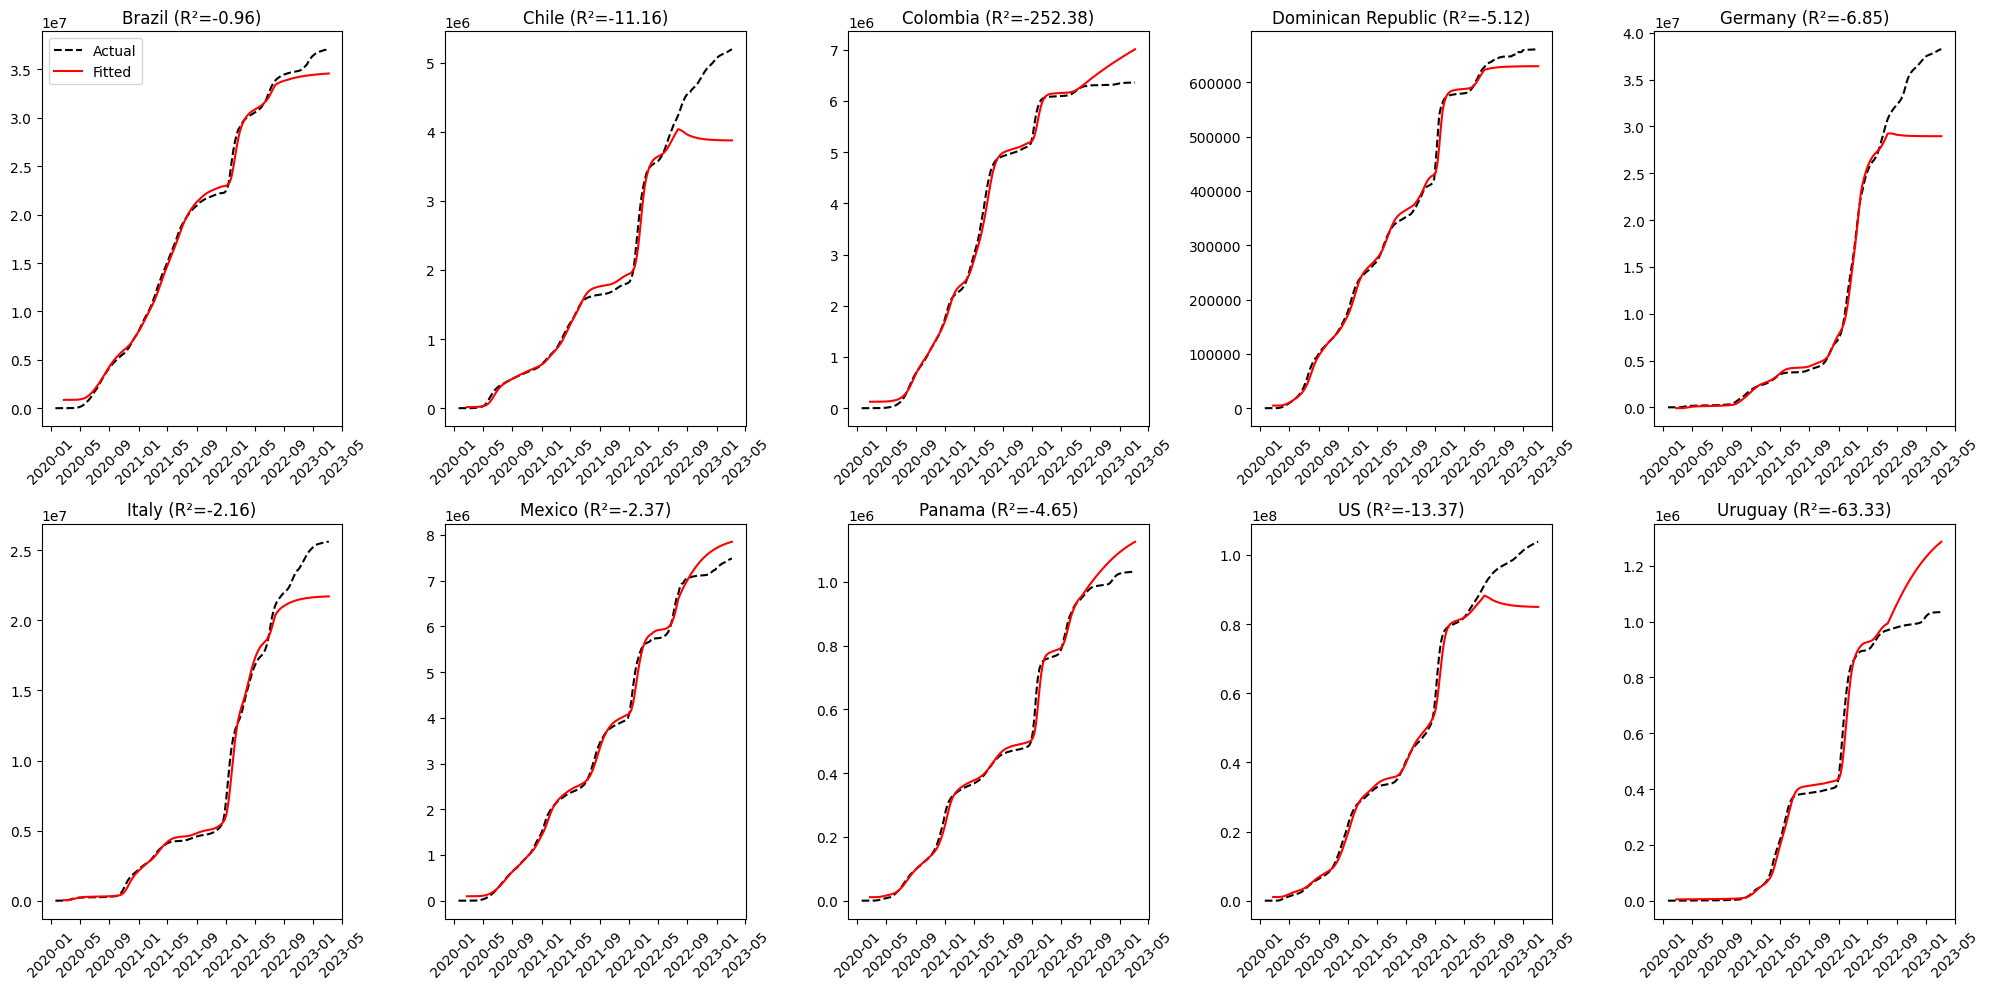

NameError: name 'reduce' is not defined

In [8]:
# ---------- helper ----------------------------------------------------------
def create_sequences(data, seq_len=5):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i + seq_len])
        y.append(data[i + seq_len])
    return np.array(X), np.array(y)

# ---------- containers ------------------------------------------------------
countries        = df_covid["country"].unique()
metrics          = {}
forecast_dfs     = []       # to build the wide table later

# ---------- plotting setup --------------------------------------------------
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes      = axes.flatten()

SEQ_LEN   = 5
EPOCHS    = 50
BATCH     = 72

for i, country in enumerate(countries):

    # ----- data prep --------------------------------------------------------
    df_cty = (df_covid.query("country == @country")
                      .loc[:, ["date", "cases"]]
                      .sort_values("date")
                      .reset_index(drop=True))
    dates  = pd.to_datetime(df_cty["date"])
    y      = df_cty["cases"].values.reshape(-1, 1)

    scaler = MinMaxScaler()
    y_scaled = scaler.fit_transform(y)

    # ----- train / test split ----------------------------------------------
    train_n = int(len(y_scaled) * 0.8)
    train, test = y_scaled[:train_n], y_scaled[train_n:]

    # sequences from TRAIN (only) for fitting
    X_train_val, y_train_val = create_sequences(train, SEQ_LEN)
    X_train_val = X_train_val.reshape((X_train_val.shape[0], SEQ_LEN, 1))

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=0.2, random_state=42, shuffle=True
    )

    # ----- GRU model --------------------------------------------------------
    model = Sequential([
        GRU(50, activation="relu", input_shape=(SEQ_LEN, 1)),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    model.fit(X_train, y_train, epochs=EPOCHS,
              batch_size=BATCH, verbose=0, shuffle=False, validation_data=(X_val, y_val))

    # -----------------------------------------------------------------------
    # 1.  fitted values for TRAIN part (one‑step‑ahead)
    # -----------------------------------------------------------------------
    train_preds_scaled = model.predict(X_train_val, verbose=0).flatten()
    train_preds = scaler.inverse_transform(
        train_preds_scaled.reshape(-1, 1)
    ).flatten()

    # aligns to indices SEQ_LEN … train_n‑1
    fitted_full = np.full(len(y), np.nan)
    fitted_full[SEQ_LEN:train_n] = train_preds

    # -----------------------------------------------------------------------
    # 2.  iterative forecasts for TEST part
    # -----------------------------------------------------------------------
    preds_test = []
    current_batch = train[-SEQ_LEN:].reshape((1, SEQ_LEN, 1))

    for _ in range(len(test)):
        pred_scaled = model.predict(current_batch, verbose=0)[0]
        preds_test.append(pred_scaled)
        current_batch = np.append(current_batch[:, 1:, :],
                                  [[pred_scaled]], axis=1)

    preds_test = scaler.inverse_transform(np.array(preds_test).reshape(-1, 1)
                 ).flatten()

    fitted_full[train_n:] = preds_test

    # -----------------------------------------------------------------------
    # 3.  metrics on TEST ----------------------------------------------------
    actual_test = scaler.inverse_transform(test).flatten()
    rmse = np.sqrt(mean_squared_error(actual_test, preds_test))
    r2   = r2_score(actual_test, preds_test)
    metrics[country] = {"RMSE": rmse, "R2": r2}

    print(f"{country:12s} | RMSE: {rmse:8.2f} | R2: {r2:6.2f}")

    # -----------------------------------------------------------------------
    # 4.  store for CSV (date & fitted)
    # -----------------------------------------------------------------------
    forecast_dfs.append(
        pd.DataFrame({"date": dates, country: fitted_full})
    )

    # -----------------------------------------------------------------------
    # 5.  plotting -----------------------------------------------------------
    ax = axes[i]
    ax.plot(dates, y.flatten(), label="Actual", color="black", ls="--")
    ax.plot(dates, fitted_full, label="Fitted", color="red")
    ax.set_title(f"{country} (R²={r2:.2f})")
    ax.tick_params(axis="x", rotation=45)
    if i == 0:
        ax.legend()

plt.tight_layout()
plt.show()



In [10]:
# ---------- build WIDE table -----------------------------------------------
wide_df = reduce(
    lambda left, right: pd.merge(left, right, on="date", how="outer"),
    forecast_dfs
).sort_values("date").set_index("date")

# ---------- save to CSV -----------------------------------------------------
out_csv = "RNN_covid.csv"
wide_df.to_csv(out_csv, date_format="%Y-%m-%d")
print(f"\nSaved fitted values to {out_csv}")


Saved fitted values to RNN_covid.csv


# Epidemics

In [14]:
df_dengue = pd.read_csv('https://raw.githubusercontent.com/danielgvb/thesis/refs/heads/main/Data/silver/dengue_no_split.csv')
df_zika = pd.read_csv('https://raw.githubusercontent.com/danielgvb/thesis/refs/heads/main/Data/silver/zika.csv')
df_chic = pd.read_csv('https://raw.githubusercontent.com/danielgvb/thesis/refs/heads/main/Data/silver/chicunguya.csv')
df_varicela = pd.read_csv('https://raw.githubusercontent.com/danielgvb/thesis/refs/heads/main/Data/silver/varicela.csv')

In [15]:
df_dengue.head()

,SEMANA,ANO,Casos,DATE
0,1,2007,315,2007-01-01
1,2,2007,236,2007-01-08
2,3,2007,252,2007-01-15
3,4,2007,305,2007-01-22
4,5,2007,360,2007-01-29


## Non-Cheating RNN

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Dengue       | RMSE: 79263.43 | R2:  -1.28


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Zika         | RMSE:  2034.48 | R2: -3912.31


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Chikungunya  | RMSE:   543.84 | R2: -151.73


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Varicela     | RMSE: 50099.97 | R2:  -4.45


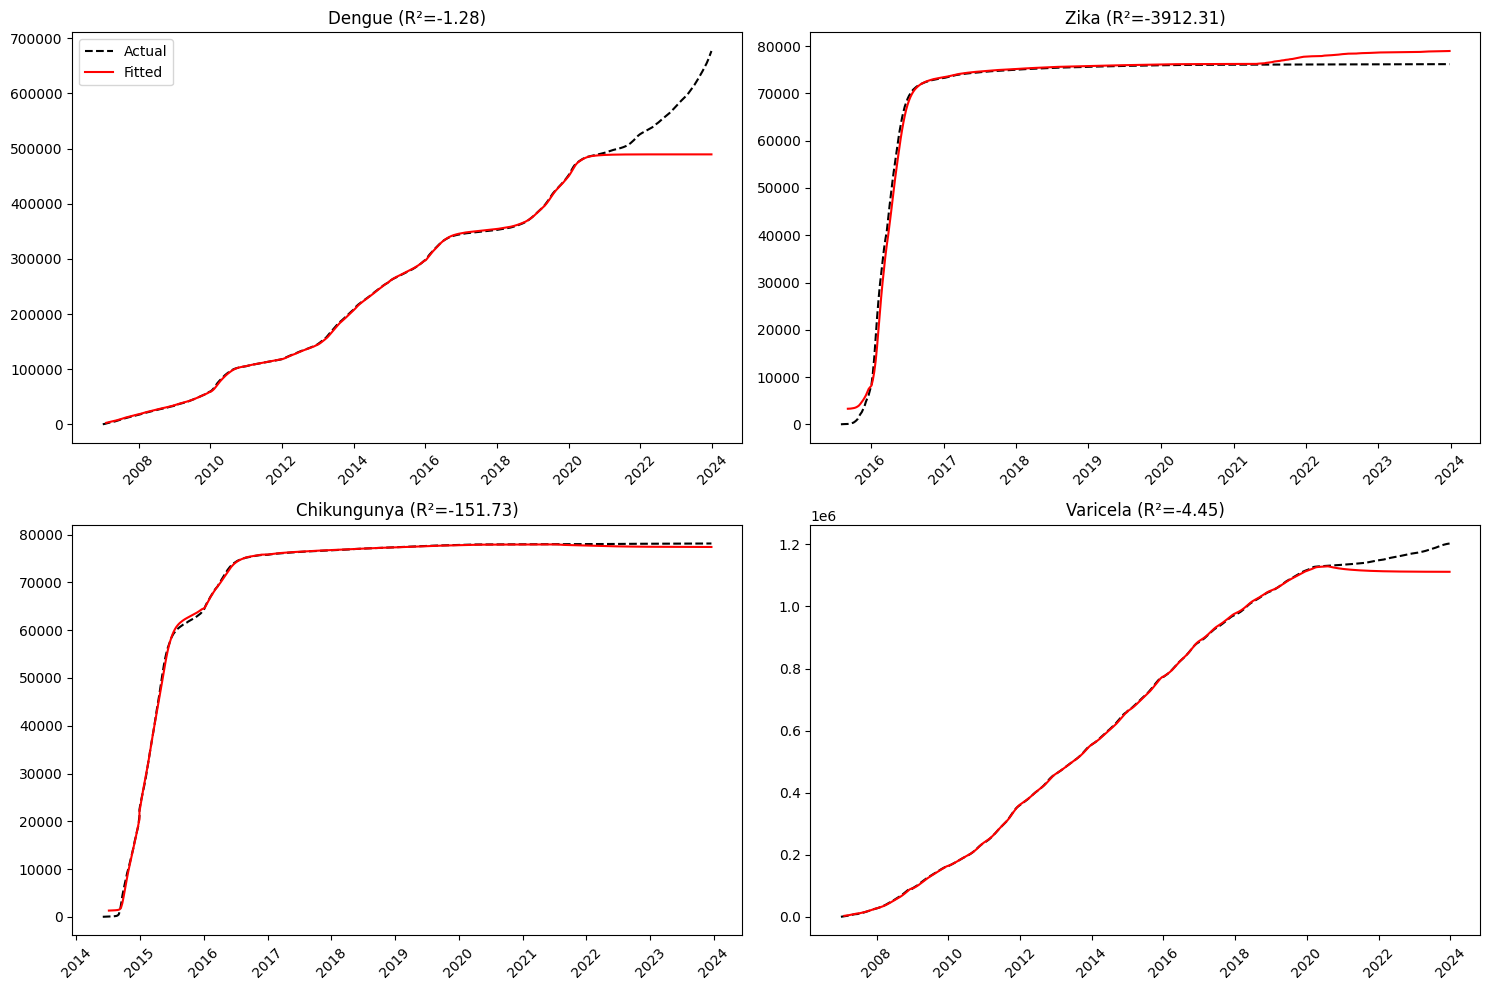


Saved fitted values to RNN_epidemics.csv


In [17]:
# ---------------------------------------------------------------------------
# helper : create (X,y) sequences of fixed length
# ---------------------------------------------------------------------------
def create_sequences(data, seq_len=5):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i : i + seq_len])
        y.append(data[i + seq_len])
    return np.array(X), np.array(y)

# ---------------------------------------------------------------------------
# raw data: dict of data‑frames ---------------------------------------------
# ---------------------------------------------------------------------------
datasets = {
    "Dengue":      df_dengue,
    "Zika":        df_zika,
    "Chikungunya": df_chic,
    "Varicela":    df_varicela,
}

SEQ_LEN  = 5
EPOCHS   = 50
BATCH    = 72

metrics       = {}
fitted_tables = []                # for the wide CSV

# plot grid
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes      = axes.flatten()

# ---------------------------------------------------------------------------
# main loop over epidemics ---------------------------------------------------
# ---------------------------------------------------------------------------
for i, (name, df_raw) in enumerate(datasets.items()):

    # -------- data prep -----------------------------------------------------
    df = (df_raw.loc[:, ["DATE", "Casos"]]
                 .rename(columns={"DATE": "date", "Casos": "y"})
                 .assign(date=lambda d: pd.to_datetime(d["date"]))
                 .sort_values("date")
                 .reset_index(drop=True))

    df["y"] = df["y"].cumsum()                    # cumulative cases

    dates   = df["date"]
    y_vals  = df["y"].values.reshape(-1, 1)

    scaler  = MinMaxScaler()
    y_scaled = scaler.fit_transform(y_vals)

    # -------- split ---------------------------------------------------------
    train_n  = int(len(y_scaled) * 0.8)
    train, test = y_scaled[:train_n], y_scaled[train_n:]

    # sequences from TRAIN only
    X_train_val, y_train_val = create_sequences(train, SEQ_LEN)
    X_train_val = X_train_val.reshape((X_train_val.shape[0], SEQ_LEN, 1))


    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=0.2, random_state=42, shuffle=True
    )

    # -------- GRU model -----------------------------------------------------
    model = Sequential([
        GRU(50, activation="relu", input_shape=(SEQ_LEN, 1)),
        Dense(1),
    ])
    model.compile(optimizer="adam", loss="mse")
    model.fit(X_train, y_train, epochs=EPOCHS,
              batch_size=BATCH, verbose=0, shuffle=False, validation_data=(X_val, y_val))

    # -------- fitted values for TRAIN (one‑step‑ahead) ----------------------
    train_pred_scaled = model.predict(X_train_val, verbose=0).flatten()
    train_pred = scaler.inverse_transform(
        train_pred_scaled.reshape(-1, 1)
    ).flatten()

    fitted_full = np.full(len(y_vals), np.nan)
    fitted_full[SEQ_LEN:train_n] = train_pred

    # -------- iterative forecasts for TEST ----------------------------------
    preds_scaled = []
    curr_batch = train[-SEQ_LEN:].reshape((1, SEQ_LEN, 1))

    for _ in range(len(test)):
        next_pred = model.predict(curr_batch, verbose=0)[0]
        preds_scaled.append(next_pred)
        curr_batch = np.append(curr_batch[:, 1:, :], [[next_pred]], axis=1)

    preds_test = scaler.inverse_transform(
        np.array(preds_scaled).reshape(-1, 1)
    ).flatten()
    fitted_full[train_n:] = preds_test

    # -------- metrics on TEST ----------------------------------------------
    actual_test = scaler.inverse_transform(test).flatten()
    rmse = np.sqrt(mean_squared_error(actual_test, preds_test))
    r2   = r2_score(actual_test, preds_test)
    metrics[name] = {"RMSE": rmse, "R2": r2}
    print(f"{name:12s} | RMSE: {rmse:8.2f} | R2: {r2:6.2f}")

    # -------- store for wide CSV -------------------------------------------
    fitted_tables.append(
        pd.DataFrame({"date": dates, name: fitted_full})
    )

    # -------- plotting ------------------------------------------------------
    ax = axes[i]
    ax.plot(dates, y_vals.flatten(), label="Actual", color="black", ls="--")
    ax.plot(dates, fitted_full,       label="Fitted", color="red")
    ax.set_title(f"{name} (R²={r2:.2f})")
    ax.tick_params(axis="x", rotation=45)
    if i == 0:
        ax.legend()

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# merge all fitted tables into a wide, date‑indexed frame --------------------
# ---------------------------------------------------------------------------
wide_df = reduce(
    lambda L, R: pd.merge(L, R, on="date", how="outer"),
    fitted_tables
).sort_values("date").set_index("date")

# ---------------------------------------------------------------------------
# save to CSV ----------------------------------------------------------------
# ---------------------------------------------------------------------------
out_csv = "RNN_epidemics.csv"
wide_df.to_csv(out_csv, date_format="%Y-%m-%d")
print(f"\nSaved fitted values to {out_csv}")


Download csvs

In [18]:
# download csvs stored
from google.colab import files
files.download('RNN_covid.csv')
files.download('RNN_epidemics.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>